<a href="https://colab.research.google.com/github/sabamahmoud-cyber/fuel-amount-prediction/blob/main/GGE_fuel_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2: Exploratory Data Analysis (EDA)

This notebook picks up where `fuel data cleaning.ipynb`
left off. It loads the cleaned, GGE-normalized fuel dataset produced there
(`df_gge_fuel`) and explores fuel consumption patterns by fuel
type, state, and transit mode  all on a directly comparable
Gasoline-Gallon-Equivalent (GGE) basis, so totals can be summed and compared
like-for-like across fuel types.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup

In [ ]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



## 2. Load Cleaned Data

Loads the GGE-converted outputs saved at the end of Part 1:
 `df_gge_fuel` (long/tidy, one row per agency + mode + fuel type, with reported amounts only).

In [2]:
import pandas as pd
path =  r'/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/06-AdvancedML/Week24/Data/cleaned_dataset.csv.xlsx'
df = pd.read_excel(path)
df.head()
print(f"df:       {df.shape}")
df[["agency", "state", "mode_name", "Fuel Type", "Amount_Original", "GGE"]].head()

df:       (2942, 34)


,agency,state,mode_name,Fuel Type,Amount_Original,GGE
0,"King County, dba: King County Metro",WA,Demand Response,Diesel,17880,20025.60
1,"King County, dba: King County Metro",WA,Bus,Diesel,43135,48311.20
2,"King County, dba: King County Metro",WA,Bus,Diesel,7006268,7847020.16
3,"King County, dba: King County Metro",WA,Ferryboat,Diesel,5591,6261.92
4,Spokane Transit Authority,WA,Demand Response,Diesel,30325,33964.00


## EDA 1  Fuel Amount by Type

All fuel types are compared on the same GGE basis.

In [ ]:
fuel_by_type = (
    df.groupby("Fuel Type")["GGE"]
    .sum()
    .sort_values(ascending=False)
)

fuel_by_type

Fuel Type
Diesel                 4.809942e+08
Electric Propulsion    1.818292e+08
CNG                    1.811236e+08
Gasoline               9.020856e+07
Biodiesel              3.596538e+07
LPG                    6.341363e+06
Other Fuel             5.258123e+06
Electric Battery       2.141713e+06
Hydrogen               3.282160e+05
Name: GGE, dtype: float64

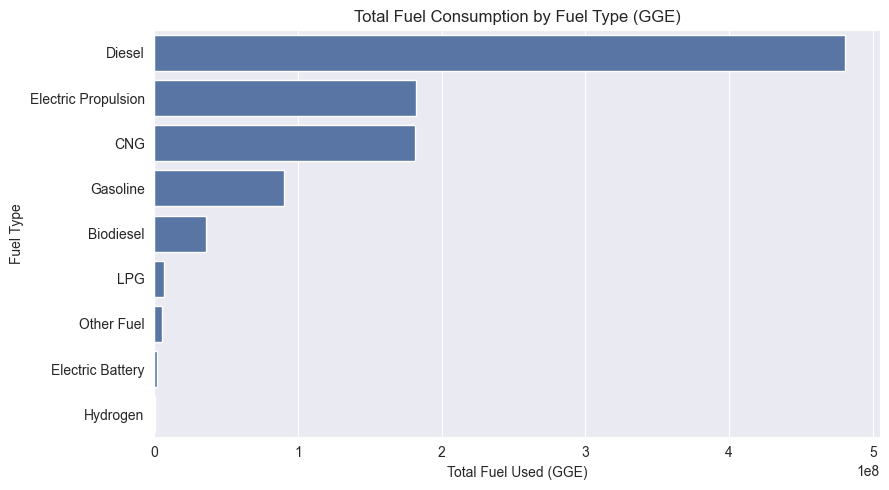

In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(x=fuel_by_type.values, y=fuel_by_type.index, color="#4C72B0")
plt.xlabel("Total Fuel Used (GGE)")
plt.ylabel("Fuel Type")
plt.title("Total Fuel Consumption by Fuel Type (GGE)")
plt.tight_layout()
plt.show()

## EDA 2 Top States

States are ordered by total reported fuel consumption after conversion to GGE.

In [ ]:
TOP_N_STATES = 15

state_totals = (
    df.groupby("state")["GGE"]
    .sum()
    .sort_values(ascending=False)
)

top_states = state_totals.head(TOP_N_STATES)
top_states

state
NY    1.795827e+08
CA    1.563445e+08
IL    7.004004e+07
NJ    6.574250e+07
TX    5.617199e+07
FL    4.762620e+07
WA    4.759249e+07
PA    4.072115e+07
MA    4.061632e+07
DC    3.025233e+07
MD    2.283012e+07
AZ    1.966526e+07
OH    1.732557e+07
VA    1.512675e+07
GA    1.468301e+07
Name: GGE, dtype: float64

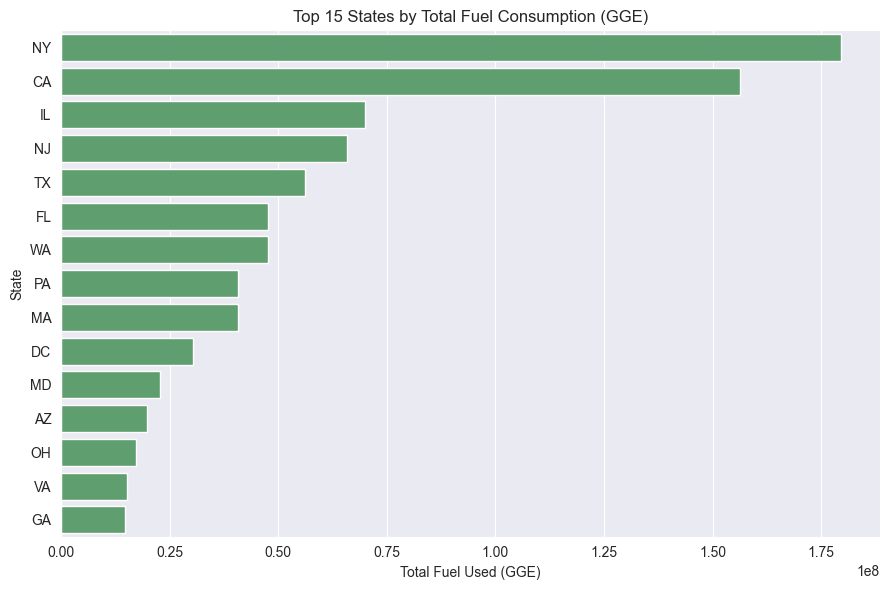

In [ ]:
plt.figure(figsize=(9, 6))
sns.barplot(x=top_states.values, y=top_states.index, color="#55A868")
plt.xlabel("Total Fuel Used (GGE)")
plt.ylabel("State")
plt.title(f"Top {TOP_N_STATES} States by Total Fuel Consumption (GGE)")
plt.tight_layout()
plt.show()

## EDA 3  Consumption by Mode

Total consumption by transit mode, measured consistently in GGE.

In [ ]:
mode_totals = (
    df.groupby("mode_name")["GGE"]
    .sum()
    .sort_values(ascending=False)
)

mode_totals

mode_name
Bus                            5.133998e+08
Commuter Rail                  1.596897e+08
Heavy Rail                     1.016079e+08
Demand Response                8.763621e+07
Ferryboat                      5.171232e+07
Light Rail                     2.635340e+07
Commuter Bus                   2.388161e+07
Vanpool                        9.138508e+06
Bus Rapid Transit              3.837449e+06
Hybrid Rail                    1.987849e+06
Streetcar Rail                 1.517319e+06
Trolleybus                     1.364336e+06
Alaska Railroad                1.090314e+06
Monorail/Automated Guideway    5.185796e+05
Publico                        3.520411e+05
Cable Car                      8.120925e+04
Inclined Plane                 1.104981e+04
Aerial Tramway                 1.083600e+04
Name: GGE, dtype: float64

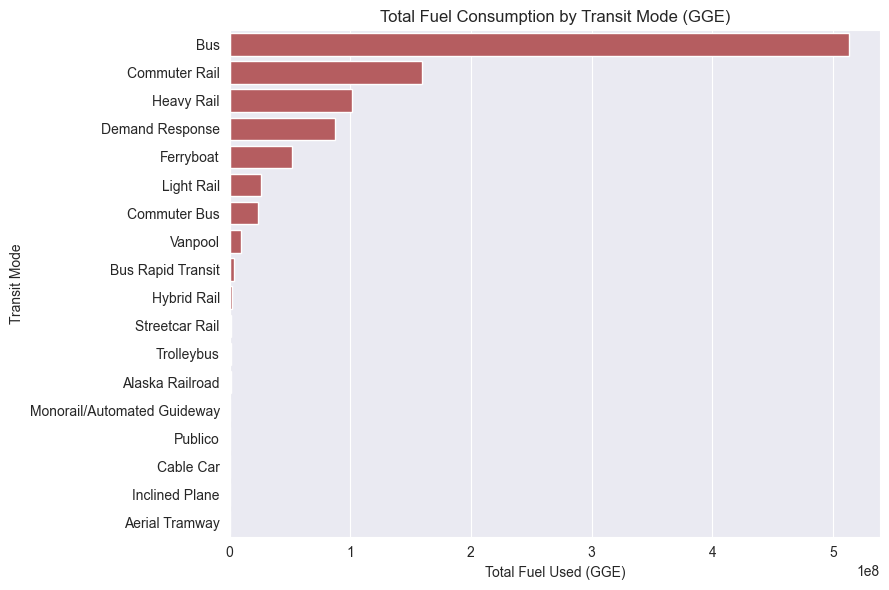

In [ ]:
plt.figure(figsize=(9, 6))
sns.barplot(x=mode_totals.values, y=mode_totals.index, color="#C44E52")
plt.xlabel("Total Fuel Used (GGE)")
plt.ylabel("Transit Mode")
plt.title("Total Fuel Consumption by Transit Mode (GGE)")
plt.tight_layout()
plt.show()

## EDA 4  Fuel Mix by Mode

Optional breakdown showing which fuel types contribute to each mode's total GGE.

In [ ]:
fuel_mix_by_mode = df.pivot_table(
    index="mode_name",
    columns="Fuel Type",
    values="GGE",
    aggfunc="sum",
    fill_value=0,
)

# Order modes the same way as EDA 3, largest total first
fuel_mix_by_mode = fuel_mix_by_mode.loc[mode_totals.index]
fuel_mix_by_mode.head()

Fuel Type,Biodiesel,CNG,Diesel,Electric Battery,Electric Propulsion,Gasoline,Hydrogen,LPG,Other Fuel
mode_name,,,,,,,,,
Bus,21293538.0,172567456.0,3.038668e+08,1817339.40,0.000000e+00,7439384.0,328216.0,1156263.32,4930833.0
Commuter Rail,8545450.2,0.0,1.008120e+08,0.00,5.033222e+07,0.0,0.0,0.00,0.0
Heavy Rail,0.0,0.0,0.000000e+00,0.00,1.016079e+08,0.0,0.0,0.00,0.0
Demand Response,829378.2,5524703.0,2.834254e+06,23060.52,0.000000e+00,73034764.0,0.0,5149097.60,240948.0
Ferryboat,1768084.5,0.0,4.994291e+07,0.00,0.000000e+00,1321.0,0.0,0.00,0.0


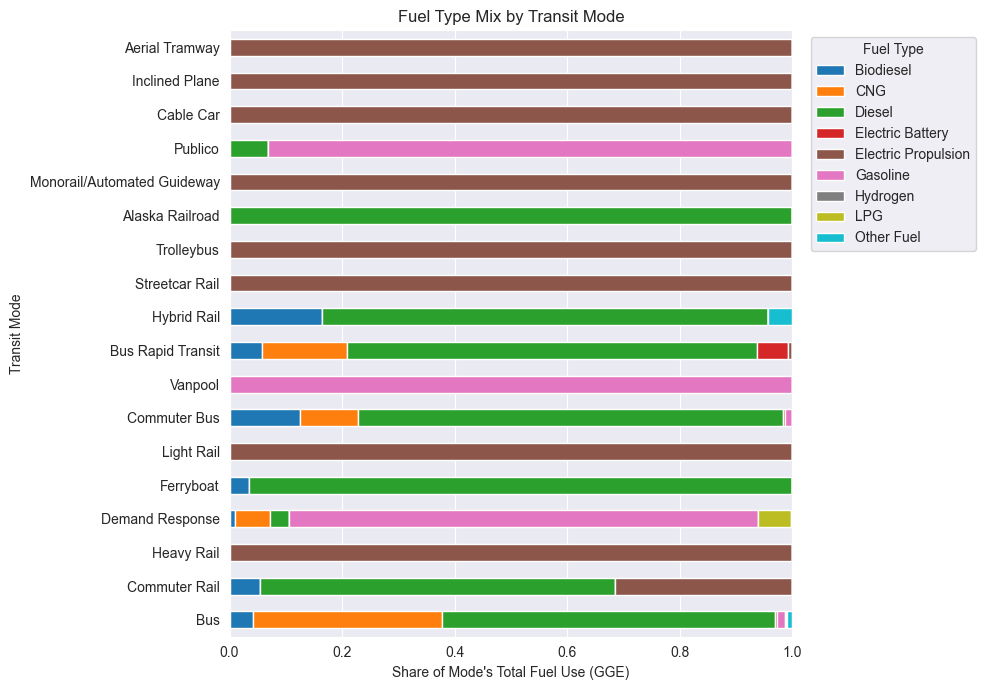

In [ ]:
fuel_mix_share = fuel_mix_by_mode.div(fuel_mix_by_mode.sum(axis=1), axis=0)

fuel_mix_share.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 7),
    colormap="tab10",
)
plt.xlabel("Share of Mode's Total Fuel Use (GGE)")
plt.ylabel("Transit Mode")
plt.title("Fuel Type Mix by Transit Mode")
plt.legend(title="Fuel Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()